#Isoform Diversity

Quantify per-gene isoform diversity across cell types and tissues using Shannon entropy of isoform usage (recollapsed counts).

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
from matplotlib import pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42      # editable text in PDF/PS (not outlines)
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

# tunable spacing (points) — override per-plot as needed
TICK_LEN = 2.0          # tick-mark length
TICK_LABEL_PAD = 1.5    # gap between ticks and tick labels
AXIS_LABEL_PAD = 1.5    # gap between axis and its axis label
PANEL_TITLE_PAD = 3.0   # gap between subplot titles and their axes (pass explicitly)
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#3. Per-gene Shannon entropy (H) of isoform usage per cell type

For each gene in each cell type, compute the mean isoform fraction across cells, then compute the Shannon entropy:

$$H = -\sum_i IF_i \cdot \log_2(IF_i)$$

H ranges from 0 (one dominant isoform) to $\log_2(n_{isoforms})$ (perfectly even usage). Unlike Pielou's J (= H / H_max), H is not normalized by the number of isoforms, so genes with more isoforms can reach higher entropy values.

In [3]:
# Read appropiate adata with isofracs

In [4]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")

# Determine gene column
gene_col = "associated_gene" if "associated_gene" in adata.var.columns else "gene_name"
print(f"Using gene column: {gene_col}")

adata

Using gene column: gene_name


AnnData object with n_obs × n_vars = 203311 × 478192
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class'
    var: 'transcript_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'isoform_fraction'

In [5]:
from scipy.sparse import csc_matrix as _csc_matrix

def shannon_entropy(fracs):
    """Compute Shannon entropy from an array of fractions (summing to ~1)."""
    fracs = fracs[fracs > 0]
    if len(fracs) == 0:
        return 0.0
    return -np.sum(fracs * np.log2(fracs))

frac_mat = adata.layers["isoform_fraction"]
genes = adata.var[gene_col].values

# Build isoform-to-gene mapping matrix for vectorized n_expr computation
unique_genes, gene_indices = np.unique(genes, return_inverse=True)
n_genes_unique = len(unique_genes)
n_isoforms = len(genes)

# Sparse matrix (n_isoforms x n_genes): multiplying binary expression matrix
# by this yields per-gene expression counts per cell
iso_to_gene = _csc_matrix(
    (np.ones(n_isoforms, dtype=np.float32), (np.arange(n_isoforms), gene_indices)),
    shape=(n_isoforms, n_genes_unique)
)

# Precompute column indices per gene for fast numpy slicing
gene_col_indices = [np.where(gene_indices == g)[0] for g in range(n_genes_unique)]

# Convert to CSC for efficient column-sum operations
if issparse(frac_mat):
    frac_csc = frac_mat.tocsc()
else:
    frac_csc = frac_mat

cell_types = sorted([ct for ct in adata.obs["cell_ontology_class"].unique() if ct != "unknown"])
print(f"Computing Shannon entropy (H) for {n_genes_unique} genes x {len(cell_types)} cell types")

entropy_records = []
for ct_i, ct in enumerate(cell_types):
    ct_mask = (adata.obs["cell_ontology_class"] == ct).values
    n_cells_ct = ct_mask.sum()
    if n_cells_ct < 10:
        continue

    frac_ct = frac_csc[ct_mask, :]

    # Column sums: total isoform fraction per isoform across all cells of this type
    col_sums = np.asarray(frac_ct.sum(axis=0)).ravel()

    # Number of expressing cells per gene via sparse matmul:
    # binary(n_cells x n_isoforms) @ iso_to_gene(n_isoforms x n_genes) -> (n_cells x n_genes)
    # then count rows > 0 per gene
    gene_expr_per_cell = (frac_ct > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    # Compute Shannon entropy per gene
    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) == 0:
            continue
        H = float(-np.sum(mean_fracs * np.log2(mean_fracs)))
        entropy_records.append({"gene": unique_genes[g_idx], "cell_ontology_class": ct, "entropy": H,
                                 "n_isoforms": n_iso, "n_cells_expr": n_expr})

    if (ct_i + 1) % 20 == 0:
        print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")

print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")
entropy_df = pd.DataFrame(entropy_records)
print(f"Entropy table: {entropy_df.shape[0]} gene-celltype pairs")
print(f"Shannon entropy (H) range: [{entropy_df['entropy'].min():.4f}, {entropy_df['entropy'].max():.4f}]")
entropy_df.head(10)

Computing Shannon entropy (H) for 26940 genes x 144 cell types
  Processed 20 / 144 cell types
  Processed 40 / 144 cell types
  Processed 60 / 144 cell types
  Processed 80 / 144 cell types
  Processed 100 / 144 cell types
  Processed 120 / 144 cell types
  Processed 144 / 144 cell types
Entropy table: 1092139 gene-celltype pairs
Shannon entropy (H) range: [-0.0000, 6.4568]


,gene,cell_ontology_class,entropy,n_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1106
1,A1BG,acinar cell of salivary gland,0.155563,9,133
2,A1BG-AS1,acinar cell of salivary gland,2.222192,20,11
3,A2M,acinar cell of salivary gland,0.998632,43,357
4,A4GALT,acinar cell of salivary gland,1.871149,22,162
5,AAAS,acinar cell of salivary gland,2.025579,24,127
6,AACS,acinar cell of salivary gland,1.965557,14,183
7,AAGAB,acinar cell of salivary gland,2.218481,18,76
8,AAK1,acinar cell of salivary gland,0.501585,32,396
9,AAMDC,acinar cell of salivary gland,3.589361,83,191


In [6]:
# Save per-gene per-cell-type isoform diversity (Shannon entropy H)
entropy_df.to_csv("./../csvs/per_gene_celltype_isoform_diversity_shannon_H.csv", index=False)
print(f"Saved {entropy_df.shape[0]} gene-celltype pairs to csvs/per_gene_celltype_isoform_diversity_shannon_H.csv")
entropy_df.head()

Saved 1092139 gene-celltype pairs to csvs/per_gene_celltype_isoform_diversity_shannon_H.csv


,gene,cell_ontology_class,entropy,n_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1106
1,A1BG,acinar cell of salivary gland,0.155563,9,133
2,A1BG-AS1,acinar cell of salivary gland,2.222192,20,11
3,A2M,acinar cell of salivary gland,0.998632,43,357
4,A4GALT,acinar cell of salivary gland,1.871149,22,162


#4. Rank genes by isoform diversity

In [7]:
# Mean Shannon entropy across cell types per gene
gene_entropy = entropy_df.groupby("gene")["entropy"].agg(["mean", "std", "count"]).reset_index()
gene_entropy.columns = ["gene", "mean_entropy", "std_entropy", "n_celltypes"]
gene_entropy = gene_entropy.sort_values("mean_entropy", ascending=False)

# --- protein-coding annotation (top-diversity lists are lncRNA/pseudogene-heavy — these are
# mostly isoseq-collapse fragmentation, not biology; restrict to protein-coding for the paper) ---
_bt = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
_g2b = (_bt.dropna(subset=["gene_name", "gene_biotype"]).drop_duplicates("gene_name")
        .set_index("gene_name")["gene_biotype"])
pc_set = set(_g2b[_g2b == "protein_coding"].index)
gene_entropy["is_pc"] = gene_entropy["gene"].isin(pc_set)

print("Top 20 highest isoform diversity genes, ALL biotypes (by Shannon entropy H):")
print(gene_entropy.head(20).to_string(index=False))

print("\nTop 20 highest isoform diversity PROTEIN-CODING genes (paper):")
print(gene_entropy[gene_entropy["is_pc"]].head(20).to_string(index=False))

print("\nTop 20 lowest isoform diversity genes (>= 5 cell types):")
low_div = gene_entropy[gene_entropy["n_celltypes"] >= 5].sort_values("mean_entropy")
print(low_div.head(20).to_string(index=False))

# Distribution of number of isoforms per gene
isoforms_per_gene = adata.var[gene_col].value_counts()
median_iso = isoforms_per_gene.median()
mean_iso = isoforms_per_gene.mean()
print(f"\nIsoforms per gene: median={median_iso:.0f}, mean={mean_iso:.1f}")

Top 20 highest isoform diversity genes, ALL biotypes (by Shannon entropy H):
              gene  mean_entropy  std_entropy  n_celltypes  is_pc
         LINC01667      4.815701     0.058501            2  False
         LARGE-AS1      4.752503     0.038950            2  False
             ADAM5      4.748069     0.050761            2  False
             LRRD1      4.618021     0.170747            2   True
         CRPPA-AS1      4.547547     0.098015            2  False
              DMKN      4.499729     1.278373           75   True
         LINC02436      4.499026     0.017220            2  False
         LINC01539      4.497212     0.001229            2  False
            MGAT4C      4.453631     0.003018            2   True
CEP164P1+ZNF22-AS1      4.451224     0.099875            2  False
          MAP9-AS1      4.427527     0.084296            2  False
        ADGRL3-AS1      4.384735     0.066304            2  False
         LINC02364      4.382409     0.311963            2  False

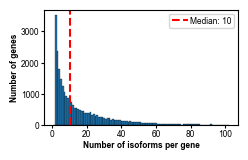

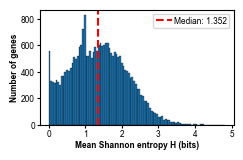

In [8]:
fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.hist(isoforms_per_gene.values, bins=np.arange(0.5, isoforms_per_gene.quantile(0.99) + 1.5, 1),
        edgecolor="black", linewidth=0.2)
ax.set_xlabel("Number of isoforms per gene")
ax.set_ylabel("Number of genes")
# ax.set_title("Distribution of isoforms per gene")
ax.axvline(median_iso, color="red", linestyle="--",
           label=f"Median: {median_iso:.0f}")
ax.legend()
plt.savefig(figpath("04_02_isoforms_per_gene_distribution.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.hist(gene_entropy["mean_entropy"], bins=100, edgecolor="black", linewidth=0.2)
ax.set_xlabel("Mean Shannon entropy H (bits)")
ax.set_ylabel("Number of genes")
# ax.set_title("Distribution of per-gene isoform diversity")
ax.axvline(gene_entropy["mean_entropy"].median(), color="red", linestyle="--",
           label=f"Median: {gene_entropy['mean_entropy'].median():.3f}")
ax.legend()
plt.savefig(figpath("04_02_per_gene_entropy_distribution.pdf"))
plt.show()

#5. Compare entropy across cell types

In [9]:
# Mean number of isoforms per gene, by cell type
ct_mean_n_isoforms = entropy_df.groupby("cell_ontology_class")["n_isoforms"].mean().sort_values(ascending=False)
median_ct_iso = ct_mean_n_isoforms.median()

# Mean Shannon entropy by cell type
ct_mean_entropy = entropy_df.groupby("cell_ontology_class")["entropy"].mean().sort_values(ascending=False)

In [10]:
# fig, ax = plt.subplots(figsize=(14, 6))
# ct_mean_n_isoforms.plot(kind="bar", ax=ax, color="steelblue")
# ax.axhline(median_ct_iso, color="red", linestyle="--", label=f"Median: {median_ct_iso:.1f}")
# ax.set_ylabel("Mean number of molecules\n (per gene)")
# ax.set_title("Mean isoforms per gene by cell type")
# ax.legend()
# plt.xticks(rotation=90)
# plt.savefig(figpath("04_02_mean_isoforms_per_gene_by_celltype.pdf"))
# plt.show()

# fig, ax = plt.subplots(figsize=(14, 6))
# ct_mean_entropy.plot(kind="bar", ax=ax, color="steelblue")
# ax.set_ylabel("Mean Shannon entropy H (bits)")
# ax.set_title("Mean isoform diversity by cell type")
# plt.xticks(rotation=90)
# plt.savefig(figpath("04_02_mean_entropy_by_celltype.pdf"))
# plt.show()

In [11]:
# cell_ontology_class -> broad_cell_class map (same mapping CSVs as section 7 / 01_08)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

_ent = entropy_df.copy()
_ent["broad_cell_class"] = _ent["cell_ontology_class"].map(
    lambda ct: ts_broad_map.get(ct, "unknown"))

# Mean number of isoforms per gene, by broad cell class (horizontal bars)
broad_mean_n_isoforms = _ent.groupby("broad_cell_class")["n_isoforms"].mean().sort_values(ascending=True)
median_broad_iso = broad_mean_n_isoforms.median()

# Mean Rényi entropy by broad cell class (horizontal bars)
broad_mean_entropy = _ent.groupby("broad_cell_class")["entropy"].mean().sort_values(ascending=True)
median_broad_entropy = broad_mean_entropy.median()


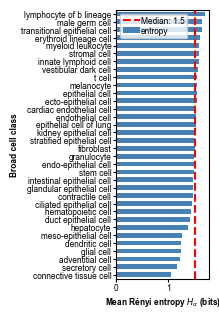

In [12]:
# fig, ax = plt.subplots(figsize=(6, 6))
# broad_mean_n_isoforms.plot(kind="barh", ax=ax, color="steelblue", width=0.9)
# ax.axvline(median_broad_iso, color="red", linestyle="--", label=f"Median: {median_broad_iso:.1f}")
# ax.set_xlabel("Mean number of molecules (per gene)")
# ax.set_ylabel("Broad cell class")
# ax.margins(y=0.005)
# ax.legend()
# plt.show()

fig, ax = plt.subplots(figsize=(1.2, 3.5))
broad_mean_entropy.plot(kind="barh", ax=ax, color="steelblue", width=0.6)
ax.axvline(median_broad_entropy, color="red", linestyle="--", label=f"Median: {median_broad_entropy:.1f}")
ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_ylabel("Broad cell class")
# ax.margins(y=0.005)
ax.legend()
plt.savefig(figpath("shannon_acorss_celltypes.pdf"))


#6. Compare entropy across tissues

In [14]:
# Compute Shannon entropy per gene per tissue (reuses frac_csc, iso_to_gene, gene_col_indices from above)
tissues = sorted(adata.obs["tissue"].unique())
tissue_entropy_records = []
for t_i, tissue in enumerate(tissues):
    t_mask = (adata.obs["tissue"] == tissue).values
    if t_mask.sum() < 10:
        continue

    frac_t = frac_csc[t_mask, :]
    col_sums = np.asarray(frac_t.sum(axis=0)).ravel()
    gene_expr_per_cell = (frac_t > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) == 0:
            continue
        H = float(-np.sum(mean_fracs * np.log2(mean_fracs)))
        tissue_entropy_records.append({"gene": unique_genes[g_idx], "tissue": tissue,
                                        "entropy": H, "n_isoforms": n_iso})

    print(f"  Tissue {t_i + 1}/{len(tissues)}: {tissue}")

tissue_entropy_df = pd.DataFrame(tissue_entropy_records)


# Mean number of isoforms per gene, by tissue (horizontal bars)
tissue_mean_n_iso = tissue_entropy_df.groupby("tissue")["n_isoforms"].mean().sort_values(ascending=True)
median_tissue_iso = tissue_mean_n_iso.median()

# Mean Rényi entropy by tissue (horizontal bars)
tissue_mean = tissue_entropy_df.groupby("tissue")["entropy"].mean().sort_values(ascending=True)
median_tissue_entropy = tissue_mean.median()

  Tissue 1/26: Bladder
  Tissue 2/26: Blood
  Tissue 3/26: Bone_Marrow
  Tissue 4/26: Ear
  Tissue 5/26: Fat
  Tissue 6/26: Heart
  Tissue 7/26: Kidney
  Tissue 8/26: Large_Intestine
  Tissue 9/26: Liver
  Tissue 10/26: Lung
  Tissue 11/26: Lymph_Node
  Tissue 12/26: Muscle
  Tissue 13/26: Ovary
  Tissue 14/26: Pancreas
  Tissue 15/26: Prostate
  Tissue 16/26: Salivary_Gland
  Tissue 17/26: Skin
  Tissue 18/26: Small_Intestine
  Tissue 19/26: Spleen
  Tissue 20/26: Stomach
  Tissue 21/26: Testis
  Tissue 22/26: Thymus
  Tissue 23/26: Tongue
  Tissue 24/26: Trachea
  Tissue 25/26: Uterus
  Tissue 26/26: Vasculature


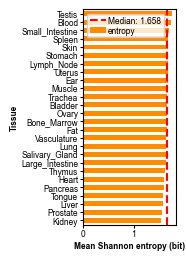

In [15]:
# fig, ax = plt.subplots(figsize=(4, 1.5))
# tissue_mean_n_iso.plot(kind="barh", ax=ax, color="darkorange", width=0.9)
# ax.axvline(median_tissue_iso, color="red", linestyle="--", label=f"Median: {median_tissue_iso:.1f}")
# ax.set_xlabel("Mean number of isoforms per gene")
# ax.set_ylabel("Tissue")
# ax.margins(y=0.005)
# ax.legend()
# plt.show()

fig, ax = plt.subplots(figsize=(1.2, 2.8))
tissue_mean.plot(kind="barh", ax=ax, color="darkorange", width=0.6)
ax.axvline(median_tissue_entropy, color="red", linestyle="--", label=f"Median: {median_tissue_entropy:.3f}")
ax.set_xlabel("Mean Shannon entropy (bit)")
ax.set_ylabel("Tissue")
ax.margins(y=0.005)
ax.legend()
plt.savefig(figpath("Shannon_acorss_tissues.pdf"))


#7. Scatter: entropy in cell type A vs cell type B

In [16]:
# Mean Shannon entropy per cell type (computed in section 5)
ct_mean_entropy = entropy_df.groupby("cell_ontology_class")["entropy"].mean().sort_values(ascending=False)

# cell_ontology_class -> broad_cell_class maps (load standard mapping CSVs, as in 01_08)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

# Map popv_prediction -> broad_cell_class (via popv_to_ts_map then ts_broad_map)
ct_to_broad = {ct: ts_broad_map.get(ct, "unknown")
               for ct in ct_mean_entropy.index}

# --- Left plot: top two highest mean entropy from the SAME broad_cell_class ---
same_pair = None
for i, ct_a in enumerate(ct_mean_entropy.index):
    for ct_b in ct_mean_entropy.index[i + 1:]:
        if ct_to_broad[ct_a] == ct_to_broad[ct_b] and ct_to_broad[ct_a] != "unknown":
            same_pair = [ct_a, ct_b]
            break
    if same_pair is not None:
        break

# --- Right plot: top two highest mean entropy from DIFFERENT broad_cell_classes ---
diff_pair = None
for i, ct_a in enumerate(ct_mean_entropy.index):
    for ct_b in ct_mean_entropy.index[i + 9:]:
        if ct_to_broad[ct_a] != ct_to_broad[ct_b]:
            diff_pair = [ct_a, ct_b]
            break
    if diff_pair is not None:
        break

# Pivot tables + correlations for the two panels
ent_pivot1 = entropy_df[entropy_df["cell_ontology_class"].isin(same_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="entropy"
).dropna()
r1 = ent_pivot1.corr().iloc[0, 1]

ent_pivot2 = entropy_df[entropy_df["cell_ontology_class"].isin(diff_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="entropy"
).dropna()
r2 = ent_pivot2.corr().iloc[0, 1]

print(f"Same broad class ({ct_to_broad[same_pair[0]]}):")
print(f"  {same_pair[0]} (mean H = {ct_mean_entropy[same_pair[0]]:.3f})")
print(f"  {same_pair[1]} (mean H = {ct_mean_entropy[same_pair[1]]:.3f})")
print(f"\nDifferent broad classes:")
print(f"  {diff_pair[0]} [{ct_to_broad[diff_pair[0]]}] (mean H = {ct_mean_entropy[diff_pair[0]]:.3f})")
print(f"  {diff_pair[1]} [{ct_to_broad[diff_pair[1]]}] (mean H = {ct_mean_entropy[diff_pair[1]]:.3f})")

Same broad class (male germ cell):
  spermatocyte (mean H = 1.731)
  spermatid (mean H = 1.679)

Different broad classes:
  spermatocyte [male germ cell] (mean H = 1.731)
  macrophage [myeloid leukocyte] (mean H = 1.694)


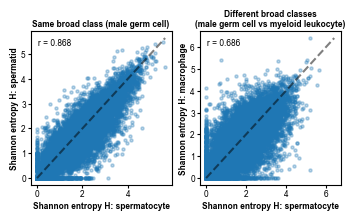

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

# --- Plot 1: Same broad class ---
ax = axes[0]
ax.scatter(ent_pivot1[same_pair[0]], ent_pivot1[same_pair[1]], alpha=0.3, s=5)
lims = [0, max(ent_pivot1.max())]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel(f"Shannon entropy H: {same_pair[0]}")
ax.set_ylabel(f"Shannon entropy H: {same_pair[1]}")
ax.set_title(f"Same broad class ({ct_to_broad[same_pair[0]]})")
ax.text(0.05, 0.95, f"r = {r1:.3f}", transform=ax.transAxes, va="top")

# --- Plot 2: Different broad classes ---
ax = axes[1]
ax.scatter(ent_pivot2[diff_pair[0]], ent_pivot2[diff_pair[1]], alpha=0.3, s=5)
lims = [0, max(ent_pivot2.max())]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel(f"Shannon entropy H: {diff_pair[0]}")
ax.set_ylabel(f"Shannon entropy H: {diff_pair[1]}")
ax.set_title(f"Different broad classes\n({ct_to_broad[diff_pair[0]]} vs {ct_to_broad[diff_pair[1]]})")
ax.text(0.05, 0.95, f"r = {r2:.3f}", transform=ax.transAxes, va="top")

plt.savefig(figpath("04_02_entropy_scatter_same_vs_diff_broadclass.pdf"))
plt.show()

#8. Genes with high between-cell-type entropy variance

In [18]:
# Per-gene Shannon entropy: mean and variance across cell types
gene_var = entropy_df.groupby("gene").agg(
    mean_entropy=("entropy", "mean"),
    var_entropy=("entropy", "var"),
    n_isoforms=("n_isoforms", "first"),  # total annotated isoforms (constant per gene)
).reset_index()
gene_var = gene_var.dropna(subset=["var_entropy"])          # genes present in >=2 cell types
gene_var = gene_var.sort_values("var_entropy", ascending=False)

# Mean dominant isoform proportion per gene (mean of max isoform fraction across expressing cells)
mean_max_frac_dict = {}
for g_idx in range(n_genes_unique):
    col_idx = gene_col_indices[g_idx]
    if len(col_idx) < 2:
        continue
    gene_fracs = frac_csc[:, col_idx]
    row_has_expr = np.array(gene_fracs.sum(axis=1)).ravel() > 0
    if row_has_expr.sum() < 5:
        continue
    mean_fracs = np.array(gene_fracs[row_has_expr].mean(axis=0)).ravel()
    mean_max_frac_dict[unique_genes[g_idx]] = mean_fracs.max()
gene_var["mean_max_isoform_proportion"] = gene_var["gene"].map(mean_max_frac_dict)

# --- Quadrant thresholds (median split of mean H and Var(H)) ---
mean_thr = gene_var["mean_entropy"].median()
var_thr = gene_var["var_entropy"].median()
hi_mean = gene_var["mean_entropy"] >= mean_thr
hi_var = gene_var["var_entropy"] >= var_thr
gene_var["quadrant"] = np.select(
    [hi_mean & ~hi_var, hi_mean & hi_var, ~hi_mean & hi_var, ~hi_mean & ~hi_var],
    ["high mean / low var", "high mean / high var", "low mean / high var", "low mean / low var"],
    default="unknown",
)
print("Genes per quadrant (median split):")
print(gene_var["quadrant"].value_counts().to_string())

print("\nn_isoforms distribution among top 100 high-variance genes:")
print(gene_var.head(100)["n_isoforms"].describe().to_string())
print(f"\nn_isoforms=2 genes: {(gene_var['n_isoforms'] == 2).sum()} / {len(gene_var)} "
      f"({(gene_var['n_isoforms'] == 2).mean():.1%})")

Genes per quadrant (median split):
quadrant
high mean / high var    8518
low mean / low var      8517
low mean / high var     4524
high mean / low var     4524

n_isoforms distribution among top 100 high-variance genes:
count    100.000000
mean      24.580000
std       18.276319
min        5.000000
25%       12.000000
50%       18.000000
75%       31.000000
max      113.000000

n_isoforms=2 genes: 2886 / 26083 (11.1%)


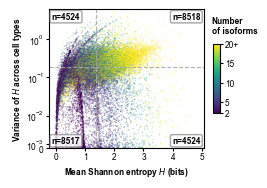

In [19]:
# --- Scatter: mean_entropy vs var_entropy, colored by n_isoforms, with quadrant split ---
fig, ax = plt.subplots(figsize=(2.5, 1.8))

# Cap colorbar at a reasonable max for visibility
n_iso_capped = gene_var["n_isoforms"].clip(upper=20)
sc_plot = ax.scatter(gene_var["mean_entropy"], gene_var["var_entropy"],
                     c=n_iso_capped, cmap="viridis", alpha=0.35, s=1, linewidths=0)

# Quadrant divider lines at the medians
ax.axvline(mean_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)
ax.axhline(var_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)

# Symlog y-axis: Var(H) is right-skewed across orders of magnitude (symlog handles exact zeros)
_pos_var = gene_var.loc[gene_var["var_entropy"] > 0, "var_entropy"]
_linthresh = float(_pos_var.quantile(0.05)) if len(_pos_var) else 1e-4
ax.set_yscale("symlog", linthresh=_linthresh, linscale=0.5)
ax.set_ylim(bottom=0)

# Annotate quadrant counts in the four corners
qcounts = gene_var["quadrant"].value_counts()
corner_kw = dict(fontsize=6, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.7))
ax.text(0.98, 0.98, f"n={qcounts.get('high mean / high var', 0)}",
        transform=ax.transAxes, ha="right", va="top", **corner_kw)
ax.text(0.02, 0.98, f"n={qcounts.get('low mean / high var', 0)}",
        transform=ax.transAxes, ha="left", va="top", **corner_kw)
ax.text(0.98, 0.02, f"n={qcounts.get('high mean / low var', 0)}",
        transform=ax.transAxes, ha="right", va="bottom", **corner_kw)
ax.text(0.02, 0.02, f"n={qcounts.get('low mean / low var', 0)}",
        transform=ax.transAxes, ha="left", va="bottom", **corner_kw)

ax.set_xlabel("Mean Shannon entropy $H$ (bits)")
ax.set_ylabel("Variance of $H$ across cell types")
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.5, aspect=10)
cbar.set_ticks([2, 5, 10, 15, 20])
cbar.set_ticklabels(["2", "5", "10", "15", "20+"])
cbar.solids.set(alpha=1.0)
cbar.set_label("Number\nof isoforms", rotation=0, labelpad=-20, y=1.4, ha="left")
plt.savefig(figpath("04_02_entropy_variance_vs_mean.pdf"))
plt.show()

#### Gene biotype composition per quadrant

In [20]:
# Gene-biotype composition per quadrant, using the gene_biotype file.
quadrant_order = ["high mean / low var", "high mean / high var",
                  "low mean / high var", "low mean / low var"]

# gene -> gene_biotype maps (by symbol, with ENSG fallback)
_bt = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
_name_bt = dict(zip(_bt["gene_name"].astype(str), _bt["gene_biotype"].astype(str)))
_ensg_bt = dict(zip(_bt["gene_id"].astype(str).str.replace(r"\..*", "", regex=True),
                    _bt["gene_biotype"].astype(str)))

def gene_to_biotype(g):
    g = str(g)
    if g in _name_bt:
        return _name_bt[g]
    return _ensg_bt.get(g.split(".")[0], "unknown")

gv = gene_var.copy()
if "quadrant" not in gv.columns:
    _hi_m = gv["mean_entropy"] >= gv["mean_entropy"].median()
    _hi_v = gv["var_entropy"] >= gv["var_entropy"].median()
    gv["quadrant"] = np.select(
        [_hi_m & ~_hi_v, _hi_m & _hi_v, ~_hi_m & _hi_v, ~_hi_m & ~_hi_v],
        quadrant_order, default="unknown")
gv["biotype"] = gv["gene"].map(gene_to_biotype)

# Consistent categories/colors: keep the globally most common biotypes, collapse rest to "other"
TOP_BIOTYPES = 6
_top_bt = gv["biotype"].value_counts().head(TOP_BIOTYPES).index.tolist()
gv["biotype_grp"] = gv["biotype"].where(gv["biotype"].isin(_top_bt), "other")
categories = _top_bt + (["other"] if (gv["biotype_grp"] == "other").any() else [])
_cmap = plt.cm.get_cmap("tab10", max(len(categories), 10))
biotype_color = {c: _cmap(i) for i, c in enumerate(categories)}

# Counts table (all biotypes, not collapsed)
bt_table = gv.groupby("quadrant")["biotype"].value_counts().unstack(fill_value=0)
print("Gene biotype counts per quadrant:")
print(bt_table.reindex(quadrant_order).to_string())

Gene biotype counts per quadrant:
biotype               IG_C_gene  IG_C_pseudogene  IG_V_gene  IG_V_pseudogene  TEC  TR_C_gene  TR_V_gene  TR_V_pseudogene  artifact  lncRNA  misc_RNA  processed_pseudogene  protein_coding  ribozyme  snoRNA  transcribed_processed_pseudogene  transcribed_unitary_pseudogene  transcribed_unprocessed_pseudogene  translated_unprocessed_pseudogene  unitary_pseudogene  unknown  unprocessed_pseudogene
quadrant                                                                                                                                                                                                                                                                                                                                                                                                  
high mean / low var           0                0          0                0    6          0          1                0         1    1480         1                    11      

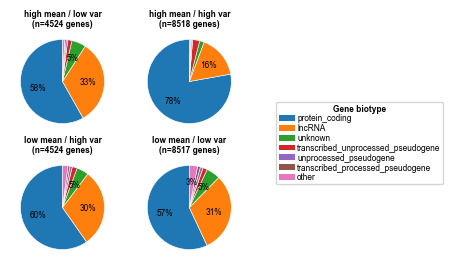

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(3, 3))
for ax, q in zip(axes.ravel(), quadrant_order):
    sub = gv[gv["quadrant"] == q]
    vc = sub["biotype_grp"].value_counts().reindex(categories).fillna(0)
    vc = vc[vc > 0]
    ax.pie(vc.values,
           colors=[biotype_color[c] for c in vc.index],
           autopct=lambda p: f"{p:.0f}%" if p >= 3 else "",
           startangle=90, textprops={"fontsize": 6},
           wedgeprops={"linewidth": 0.4, "edgecolor": "white"})
    ax.set_title(f"{q}\n(n={len(sub)} genes)", fontsize=6, pad=0.0)

# Shared legend for the biotype categories
handles = [plt.matplotlib.patches.Patch(facecolor=biotype_color[c], label=c) for c in categories]
fig.legend(handles=handles, title="Gene biotype", loc="center left",
           bbox_to_anchor=(1.0, 0.5), fontsize=6, title_fontsize=6)
fig.savefig(figpath("04_02_quadrant_biotype_pies_unnormalized.pdf"), bbox_inches="tight")
plt.show()

In [22]:
# Stacked bar: isoform proportions for one example gene from EACH mean/variance quadrant.
# Example = the "corner-most" gene in each quadrant (well-populated: >= 10 cell types).
from scipy.sparse import issparse as _issparse

max_isoforms = 8
quadrant_order = ["high mean / low var", "high mean / high var",
                  "low mean / high var", "low mean / low var"]

# Option: restrict the per-quadrant EXAMPLE gene selection to protein-coding genes only
# (the quadrant analysis itself is unchanged).
EXAMPLE_PROTEIN_CODING_ONLY = True
if EXAMPLE_PROTEIN_CODING_ONLY:
    _btx = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
    _pcx = _btx.loc[_btx["gene_biotype"].astype(str) == "protein_coding"]
    _pc_names_x = set(_pcx["gene_name"].dropna().astype(str))
    _pc_ids_x = set(_pcx["gene_id"].astype(str).str.replace(r"\..*", "", regex=True))
    if gene_col == "associated_gene":
        _is_pc = lambda g: str(g).split(".")[0] in _pc_ids_x
    else:
        _is_pc = lambda g: str(g) in _pc_names_x

# Shared precomputation
_count_mat = adata.X
count_csc = _count_mat.tocsc() if _issparse(_count_mat) else _count_mat
popv = adata.obs["cell_ontology_class"].values
_n_ct = entropy_df.groupby("gene").size()

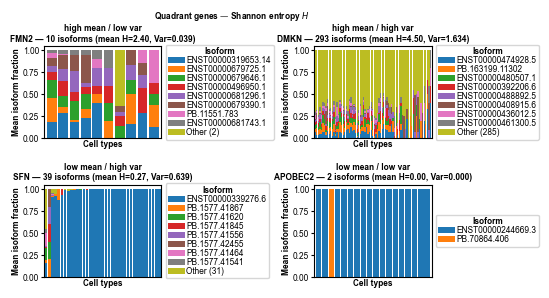

In [23]:
def pick_quadrant_examples(gv):
    """One corner-most, well-populated (>=10 cell types) gene per quadrant."""
    gv = gv.copy()
    if "quadrant" not in gv.columns:
        hi_m = gv["mean_entropy"] >= gv["mean_entropy"].median()
        hi_v = gv["var_entropy"] >= gv["var_entropy"].median()
        gv["quadrant"] = np.select(
            [hi_m & ~hi_v, hi_m & hi_v, ~hi_m & hi_v, ~hi_m & ~hi_v],
            quadrant_order, default="unknown")
    cand = gv.copy()
    cand["n_celltypes"] = cand["gene"].map(_n_ct)
    cand = cand[cand["n_celltypes"] >= 10]
    if EXAMPLE_PROTEIN_CODING_ONLY:
        cand = cand[cand["gene"].map(_is_pc)]
    r_mean = cand["mean_entropy"].rank(pct=True)
    r_var = cand["var_entropy"].rank(pct=True)
    corner_score = {
        "high mean / low var": r_mean * (1 - r_var),
        "high mean / high var": r_mean * r_var,
        "low mean / high var": (1 - r_mean) * r_var,
        "low mean / low var": (1 - r_mean) * (1 - r_var),
    }
    picks = []
    for q in quadrant_order:
        sub = cand[cand["quadrant"] == q]
        if sub.empty:
            sub = gv[gv["quadrant"] == q]
            if EXAMPLE_PROTEIN_CODING_ONLY:
                sub = sub[sub["gene"].map(_is_pc)]
            if sub.empty:
                continue
            picks.append((q, sub.iloc[0]))
            continue
        best_idx = corner_score[q].loc[sub.index].idxmax()
        picks.append((q, cand.loc[best_idx]))
    return picks

def plot_quadrant_examples(gv, metric_short, save_name):
    example_genes = pick_quadrant_examples(gv)
    fig, axes = plt.subplots(2, 2, figsize=(5, 3.0))
    for idx, (quadrant, gene_row) in enumerate(example_genes):
        ax = axes[idx // 2, idx % 2]
        gene_name = gene_row["gene"]

        gene_iso_mask = adata.var[gene_col].values == gene_name
        gene_iso_idx = np.where(gene_iso_mask)[0]
        gene_iso_names = adata.var.index[gene_iso_mask].tolist()

        # Slice this gene's isoform COLUMNS once (fast on CSC), then densify the small block.
        Fg = frac_csc[:, gene_iso_idx]
        Fg = Fg.toarray() if _issparse(Fg) else np.asarray(Fg)
        Cg = count_csc[:, gene_iso_idx]
        Cg = Cg.toarray() if _issparse(Cg) else np.asarray(Cg)

        gene_entropy_sub = entropy_df[entropy_df["gene"] == gene_name].sort_values("entropy", ascending=False)
        gene_cts = gene_entropy_sub["cell_ontology_class"].tolist()

        frac_records = []
        count_records = []
        for ct in gene_cts:
            m = popv == ct
            subF = Fg[m]
            expressing = subF.sum(axis=1) > 0
            if expressing.sum() < 5:
                continue
            mean_fracs = subF[expressing].mean(axis=0)
            total_counts = Cg[m][expressing].sum(axis=0)
            for j, iso in enumerate(gene_iso_names):
                frac_records.append({"cell_ontology_class": ct, "isoform": iso, "mean_fraction": mean_fracs[j]})
                count_records.append({"cell_ontology_class": ct, "isoform": iso, "total_count": int(total_counts[j])})

        frac_df = pd.DataFrame(frac_records)
        frac_pivot = frac_df.pivot_table(index="cell_ontology_class", columns="isoform", values="mean_fraction", fill_value=0)
        count_df_pivot = pd.DataFrame(count_records).pivot_table(index="cell_ontology_class", columns="isoform", values="total_count", fill_value=0)

        iso_means = frac_pivot.mean(axis=0).sort_values(ascending=False)
        top_isos = iso_means.head(max_isoforms).index.tolist()
        other_cols = [c for c in frac_pivot.columns if c not in top_isos]
        plot_df = frac_pivot[top_isos].copy()
        count_plot = count_df_pivot.reindex(columns=top_isos, fill_value=0).copy()
        if len(other_cols) > 0:
            other_sum = frac_pivot[other_cols].sum(axis=1)
            other_count_sum = count_df_pivot[[c for c in other_cols if c in count_df_pivot.columns]].sum(axis=1)
            if other_sum.sum() > 0:
                plot_df["Other"] = other_sum
                count_plot["Other"] = other_count_sum

        ct_order = [ct for ct in gene_cts if ct in plot_df.index]
        plot_df = plot_df.reindex(ct_order)
        count_plot = count_plot.reindex(ct_order)

        plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=False)

        ax.set_xlabel("Cell types")
        ax.set_ylabel("Mean isoform fraction")
        ax.set_xticks([])
        ax.set_title(f"{quadrant}\n{gene_name} — {len(gene_iso_names)} isoforms "
                     f"(mean {metric_short}={gene_row['mean_entropy']:.2f}, Var={gene_row['var_entropy']:.3f})",
                     pad=PANEL_TITLE_PAD)
        other_count = len(other_cols)
        legend_labels = list(plot_df.columns[:-1]) + [f"Other ({other_count})"] if "Other" in plot_df.columns else list(plot_df.columns)
        leg = ax.legend(legend_labels, title="Isoform",
                  loc=6, bbox_to_anchor=(1.0, 0.5), labelspacing=0.0, ncol=1)
        leg.get_title().set_fontweight("bold")

    metric_name = {"H": "Shannon entropy $H$"}.get(metric_short, metric_short)
    fig.suptitle(f"Quadrant genes — {metric_name}", y=1.00)
    plt.subplots_adjust(wspace=1.3, hspace=0.5)
    fig.savefig(save_name)
    plt.show()

plot_quadrant_examples(gene_var, "H",
                       "figures/04_02_quadrant_example_genes_stackedbar_unnormalized.pdf")